This notebook merges observations from 15 m depth drogued drifters in the Med Sea during the SWOT CalVal period.

In [1]:
import os

import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
all_time = []
all_lat = []
all_lon = []
all_ve = []
all_vn = []
all_id = []
all_type = []

for file in os.listdir("data/SWOT-CalVal_Med_drifters/l2_data_variational_1hour/"):
    ds = xr.open_dataset(f"data/SWOT-CalVal_Med_drifters/l2_data_variational_1hour/{file}", decode_timedelta=False)

    if ds.attrs["drogue_depth"] != 15:
        continue
    else:
        print(f"Processing file: {file}")

    n_obs = len(ds["TIME"])

    all_time.append(ds["TIME"].values)
    all_lat.append(ds["LATITUDE"].values)
    all_lon.append(ds["LONGITUDE"].values)
    all_ve.append(ds["VELOCITY_EAST"].values)
    all_vn.append(ds["VELOCITY_NORTH"].values)
    all_id.append(np.repeat(ds.id, n_obs))
    all_type.append(np.repeat(ds.sensor[9:-5], n_obs))

all_time = np.concatenate(all_time)
all_lat = np.concatenate(all_lat)
all_lon = np.concatenate(all_lon)
all_ve = np.concatenate(all_ve)
all_vn = np.concatenate(all_vn)
all_id = np.concatenate(all_id)
all_type = np.concatenate(all_type)

Processing file: FAST-SWOT_SVP-B_6204607.nc
Processing file: BIOSWOT_SVPOGS_300534064104890.nc
Processing file: C-SWOT_SVP_300534060011620.nc
Processing file: BIOSWOT_SVPSIO_300534064300510.nc
Processing file: C-SWOT_SVP_300534060015760.nc
Processing file: C-SWOT_SVP_300534062479690.nc
Processing file: FAST-SWOT_SVP-B_6204606.nc
Processing file: BIOSWOT_SVPOGS_300534064108950.nc
Processing file: BIOSWOT_SVPSIO_300534064300460.nc
Processing file: C-SWOT_SVP_300534060211000.nc
Processing file: C-SWOT_SVP_300534060218400.nc
Processing file: C-SWOT_SVP_300534062471390.nc
Processing file: C-SWOT_SVP_300534062474750.nc
Processing file: BIOSWOT_SVPSIO_300534061395960.nc
Processing file: C-SWOT_SVP_300534060012760.nc
Processing file: BIOSWOT_SVPOGS_300534064109870.nc
Processing file: BIOSWOT_SVPOGS_300534064107880.nc
Processing file: BIOSWOT_SVPSIO_300534061395970.nc
Processing file: C-SWOT_SVP_300534060216070.nc
Processing file: BIOSWOT_SVPOGS_300534064103890.nc
Processing file: C-SWOT_SVP_30

In [3]:
drifter_ds = xr.Dataset(
    {
        "time": (("points",), all_time, ds["TIME"].attrs),
        "latitude": (("points",), all_lat, ds["LATITUDE"].attrs),
        "longitude": (("points",), all_lon, ds["LONGITUDE"].attrs),
        "velocity_east": (("points",), all_ve, ds["VELOCITY_EAST"].attrs),
        "velocity_north": (("points",), all_vn, ds["VELOCITY_NORTH"].attrs),
        "drifter_id": (("points",), all_id, {"long_name": "Drifter Identifier"}),
        "drifter_type": (("points",), all_type, {"long_name": "Drifter Type"}),
    },
    coords={"points": np.arange(len(all_time))},
    attrs={
        "summary": "This dataset is a subset of the observations of SVP-types Lagrangian surface drifters that were "
        "deployed in the Western Mediterranean sea in 2023 by three campaigns of the SWOT Adopt-A-Crossover Consortium:"
        " C-SWOT-2023, BioSWOT-Med and FaSt-SWOT. It contains only the drifters with drogues at 15 m depth.",
        "original_dataset": "http://doi.org/10.17882/100828",
        "processing_level": "Smoothed and regularly interpolated trajectories (Variational, 1hour)"
    }
)

In [4]:
drifter_ds = drifter_ds.where(
    (
        (drifter_ds.time >= np.datetime64("2023-03-28T00:00:00")).compute() & 
        (drifter_ds.time <= np.datetime64("2023-07-11T23:59:59")).compute()
    ), 
    drop=True
)

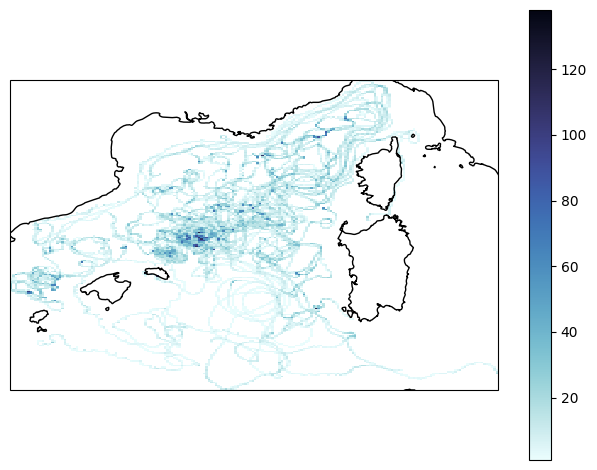

In [5]:
fig = plt.figure()
ax = fig.add_subplot(projection=ccrs.PlateCarree())

im = ax.hist2d(drifter_ds.longitude, drifter_ds.latitude, bins=200, cmap=cmo.ice_r, cmin=1)[-1]

fig.colorbar(im, ax=ax, orientation="vertical")
ax.coastlines()

fig.tight_layout()

plt.show()

In [6]:
drifter_ds.to_zarr("data/drifters_drogue15m_CalVal.zarr", mode="w")

/Users/bertrava/miniforge3/envs/swot-cyclogeo/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
